# SUMO Traffic Light Control - Training Analysis

This notebook analyzes training metrics from DQN agent training runs.
It loads metrics from the `output/` directory and provides comprehensive visualizations.


In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional
import glob

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
OUTPUT_DIR = Path("output")

print("Libraries imported successfully!")


Libraries imported successfully!


## Load Training Metrics

Select a run ID or load the most recent run automatically.


In [5]:
def load_metrics(run_id: Optional[str] = None) -> tuple[Dict, Dict, Path]:
    """Load metrics and config for a specific run."""
    if run_id is None:
        # Find most recent run
        runs = sorted(OUTPUT_DIR.glob("*/"), key=lambda p: p.stat().st_mtime, reverse=True)
        if not runs:
            raise ValueError(f"No runs found in {OUTPUT_DIR}")
        run_dir = runs[0]
        run_id = run_dir.name
        print(f"Loading most recent run: {run_id}")
    else:
        run_dir = OUTPUT_DIR / run_id
    
    metrics_file = run_dir / "metrics.json"
    config_file = run_dir / "config.json"
    
    if not metrics_file.exists():
        raise FileNotFoundError(f"Metrics file not found: {metrics_file}")
    
    with open(metrics_file) as f:
        metrics = json.load(f)
    
    config = {}
    if config_file.exists():
        with open(config_file) as f:
            config = json.load(f)
    
    return metrics, config, run_dir

# Load metrics (change run_id to analyze a specific run)
# Set to None to load most recent, or specify a run_id like "20251109_204535_7ead7c5a"
RUN_ID = "20251109_204535_7ead7c5a"  # Change to specific run_id or None for most recent
metrics, config, run_dir = load_metrics(RUN_ID)

df = None  # Will hold episode-level DataFrame once constructed

print(f"\nLoaded metrics for run: {metrics.get('run_id', 'unknown')}")
print(f"Mode: {metrics.get('mode', 'unknown')}")
print(f"Episodes: {metrics.get('episodes', 0)}")
if metrics.get('mode') == 'multi_agent_training':
    print(f"Number of agents: {metrics.get('num_agents', 0)}")
    print(f"Agent IDs: {metrics.get('tls_ids', [])}")



Loaded metrics for run: 20251109_204535_7ead7c5a
Mode: multi_agent_training
Episodes: 50
Number of agents: 4
Agent IDs: ['group_0', 'group_1', 'group_2', 'group_3']


## Learning Diagnostics

Check if the agent is learning or if metrics are flat (indicating no learning progress).


In [6]:
if df is not None:
    # Check for flat metrics (no learning)
    reward_col = 'reward' if 'reward' in df.columns else 'total_reward'
    reward_std = df[reward_col].std()
    queues_std = df['total_queues'].std() if 'total_queues' in df.columns else 0
    waiting_std = df['total_waiting_time'].std() if 'total_waiting_time' in df.columns else 0
    
    reward_change = abs(df[reward_col].iloc[-1] - df[reward_col].iloc[0])
    queues_change = abs(df['total_queues'].iloc[-1] - df['total_queues'].iloc[0]) if 'total_queues' in df.columns else 0
    waiting_change = abs(df['total_waiting_time'].iloc[-1] - df['total_waiting_time'].iloc[0]) if 'total_waiting_time' in df.columns else 0
    
    # Thresholds for detecting flat metrics
    REWARD_THRESHOLD = 100  # Minimum change in reward to indicate learning
    QUEUES_THRESHOLD = 1    # Minimum change in queues
    WAITING_THRESHOLD = 10  # Minimum change in waiting time
    
    print("=" * 80)
    print("LEARNING DIAGNOSTICS")
    print("=" * 80)
    
    issues = []
    
    if reward_std < 1.0 or reward_change < REWARD_THRESHOLD:
        issues.append("⚠️  REWARD is FLAT - No improvement detected!")
        print(f"\n⚠️  WARNING: Reward metrics show NO LEARNING!")
        print(f"   - Reward std: {reward_std:.2f} (very low variation)")
        print(f"   - Reward change: {reward_change:.2f} (should be > {REWARD_THRESHOLD})")
        print(f"   - Initial reward: {df[reward_col].iloc[0]:.2f}")
        print(f"   - Final reward: {df[reward_col].iloc[-1]:.2f}")
    
    if queues_std < 0.1 or queues_change < QUEUES_THRESHOLD:
        issues.append("⚠️  QUEUES are FLAT - No improvement detected!")
        print(f"\n⚠️  WARNING: Queue metrics show NO LEARNING!")
        print(f"   - Queue std: {queues_std:.2f} (very low variation)")
        print(f"   - Queue change: {queues_change:.0f} (should be > {QUEUES_THRESHOLD})")
        print(f"   - Initial queues: {df['total_queues'].iloc[0]:.0f}")
        print(f"   - Final queues: {df['total_queues'].iloc[-1]:.0f}")
    
    if waiting_std < 1.0 or waiting_change < WAITING_THRESHOLD:
        issues.append("⚠️  WAITING TIME is FLAT - No improvement detected!")
        print(f"\n⚠️  WARNING: Waiting time metrics show NO LEARNING!")
        print(f"   - Waiting std: {waiting_std:.2f} (very low variation)")
        print(f"   - Waiting change: {waiting_change:.2f} (should be > {WAITING_THRESHOLD})")
        print(f"   - Initial waiting: {df['total_waiting_time'].iloc[0]:.2f}s")
        print(f"   - Final waiting: {df['total_waiting_time'].iloc[-1]:.2f}s")
    
    if issues:
        print("\n" + "=" * 80)
        print("🔴 CRITICAL: Agent shows NO LEARNING PROGRESS!")
        print("=" * 80)
        print("\nPossible causes:")
        print("1. ❌ Traffic too heavy - Agent cannot learn (check flow_rate parameter)")
        print("2. ❌ Learning rate too low - Agent learns too slowly")
        print("3. ❌ Reward function not working - Agent gets no useful feedback")
        print("4. ❌ Network too small - Agent cannot represent good policies")
        print("5. ❌ Exploration too low - Agent stuck in local minimum")
        print("\n💡 Recommendations:")
        print("   • Retrain with CORRECTED flow_rate (use --insertion-rate instead of -p)")
        print("   • Try lower flow_rate (e.g., 400-600 vehicles/hour)")
        print("   • Check if reward function is providing meaningful signals")
        print("   • Verify network architecture is appropriate for the problem")
        print("   • Consider using ImprovedDQNAgent (--agent-type improved)")
        print("=" * 80)
    else:
        print("\n✅ Learning progress detected - metrics are changing over time")
        print(f"   - Reward improved by: {reward_change:.2f}")
        print(f"   - Queues changed by: {queues_change:.0f}")
        print(f"   - Waiting time changed by: {waiting_change:.2f}s")
    
    print()


## Convert to DataFrame

Convert episode data to a pandas DataFrame for easier analysis.


In [7]:
if metrics.get('mode') in ['training', 'multi_agent_training', 'centralized_training'] and 'episode_data' in metrics:
    df = pd.DataFrame(metrics['episode_data'])
    
    # Handle different modes
    if metrics.get('mode') == 'multi_agent_training':
        # Multi-agent mode: use total_reward and avg_epsilon
        if 'total_reward' in df.columns:
            df['reward'] = df['total_reward']  # Alias for compatibility
        if 'avg_epsilon' in df.columns:
            df['epsilon'] = df['avg_epsilon']  # Alias for compatibility
    elif metrics.get('mode') == 'centralized_training':
        # Centralized mode: same structure as single-agent
        pass
    # Single-agent mode: already has 'reward' and 'epsilon'
    
    # Calculate additional metrics (only for single-agent mode with per-lane data)
    if 'queues' in df.columns and df['queues'].notna().any():
        df['avg_queue_per_lane'] = df['queues'].apply(lambda x: np.mean(x) if isinstance(x, list) and x else 0)
        df['max_queue'] = df['queues'].apply(lambda x: max(x) if isinstance(x, list) and x else 0)
    if 'waiting_times' in df.columns and df['waiting_times'].notna().any():
        df['avg_waiting_per_lane'] = df['waiting_times'].apply(lambda x: np.mean(x) if isinstance(x, list) and x else 0)
        df['max_waiting'] = df['waiting_times'].apply(lambda x: max(x) if isinstance(x, list) and x else 0)
    
    # Calculate moving averages
    window = min(10, len(df) // 4)
    if 'reward' in df.columns:
        df['reward_ma'] = df['reward'].rolling(window=window, center=True).mean()
    if 'total_queues' in df.columns:
        df['queues_ma'] = df['total_queues'].rolling(window=window, center=True).mean()
    if 'total_waiting_time' in df.columns:
        df['waiting_ma'] = df['total_waiting_time'].rolling(window=window, center=True).mean()
    
    if 'avg_loss' in df.columns:
        df['loss_ma'] = df['avg_loss'].rolling(window=window, center=True).mean()
    
    print(f"DataFrame shape: {df.shape}")
    print(f"\nFirst few episodes:")
    cols = ['episode']
    if 'reward' in df.columns:
        cols.append('reward')
    if 'epsilon' in df.columns:
        cols.append('epsilon')
    if 'total_queues' in df.columns:
        cols.append('total_queues')
    if 'total_waiting_time' in df.columns:
        cols.append('total_waiting_time')
    print(df[cols].head())
    print(f"\nLast few episodes:")
    print(df[cols].tail())
else:
    print("No training episode data found. This might be an evaluation-only run.")
    df = None


DataFrame shape: (50, 16)

First few episodes:
   episode    reward   epsilon  total_queues  total_waiting_time
0        1  109452.0  0.910999             1                 7.0
1        2  108349.3  0.821899             1                27.0
2        3  108871.8  0.732799             0                 0.0
3        4  106711.7  0.643699             0                 0.0
4        5  107100.5  0.554599             1                 5.0

Last few episodes:
    episode   reward  epsilon  total_queues  total_waiting_time
45       46  62977.3     0.01             0                 0.0
46       47  52552.9     0.01             6                20.0
47       48  63479.0     0.01            23              2049.0
48       49  94161.7     0.01             3               122.0
49       50  93254.8     0.01             4                22.0


## Training Overview

Display key statistics about the training run.


In [8]:
if df is not None:
    print("=" * 80)
    print("TRAINING OVERVIEW")
    print("=" * 80)
    print(f"\nRun ID: {metrics.get('run_id')}")
    print(f"Total Episodes: {len(df)}")
    
    reward_col = 'reward' if 'reward' in df.columns else 'total_reward'
    epsilon_col = 'epsilon' if 'epsilon' in df.columns else 'avg_epsilon'
    
    print(f"\nReward Statistics:")
    print(f"  Initial (first 10): {df.head(10)[reward_col].mean():.2f}")
    print(f"  Final (last 10): {df.tail(10)[reward_col].mean():.2f}")
    print(f"  Best: {df[reward_col].max():.2f}")
    print(f"  Worst: {df[reward_col].min():.2f}")
    print(f"  Mean: {df[reward_col].mean():.2f}")
    print(f"  Std: {df[reward_col].std():.2f}")
    
    if 'total_queues' in df.columns:
        print(f"\nQueue Statistics:")
        print(f"  Initial (first 10): {df.head(10)['total_queues'].mean():.1f}")
        print(f"  Final (last 10): {df.tail(10)['total_queues'].mean():.1f}")
        print(f"  Best (lowest): {df['total_queues'].min():.0f}")
        print(f"  Worst (highest): {df['total_queues'].max():.0f}")
    
    if 'total_waiting_time' in df.columns:
        print(f"\nWaiting Time Statistics:")
        print(f"  Initial (first 10): {df.head(10)['total_waiting_time'].mean():.2f}s")
        print(f"  Final (last 10): {df.tail(10)['total_waiting_time'].mean():.2f}s")
        print(f"  Best (lowest): {df['total_waiting_time'].min():.2f}s")
    
    if epsilon_col in df.columns:
        print(f"\nEpsilon (Exploration):")
        print(f"  Start: {df[epsilon_col].iloc[0]:.3f}")
        print(f"  End: {df[epsilon_col].iloc[-1]:.3f}")
    
    # Multi-agent specific stats
    if metrics.get('mode') == 'multi_agent_training' and 'agent_rewards' in df.columns:
        print(f"\nMulti-Agent Statistics:")
        print(f"  Number of agents: {metrics.get('num_agents', 0)}")
        if 'avg_reward_per_agent' in df.columns:
            print(f"  Avg reward per agent (final): {df.tail(10)['avg_reward_per_agent'].mean():.2f}")
    
    if 'avg_loss' in df.columns and df['avg_loss'].notna().any():
        loss_data = df[df['avg_loss'].notna()]
        if len(loss_data) > 0:
            print(f"\nLoss Statistics:")
            print(f"  Mean: {loss_data['avg_loss'].mean():.6f}")
            print(f"  Final: {loss_data['avg_loss'].iloc[-1]:.6f}")
    
    if 'best_eval_reward' in metrics and metrics['best_eval_reward']:
        print(f"\nBest Evaluation Reward: {metrics['best_eval_reward']:.2f}")


TRAINING OVERVIEW

Run ID: 20251109_204535_7ead7c5a
Total Episodes: 50

Reward Statistics:
  Initial (first 10): 101870.78
  Final (last 10): 67831.47
  Best: 109452.00
  Worst: -165509.40
  Mean: 56387.92
  Std: 54597.71

Queue Statistics:
  Initial (first 10): 1.2
  Final (last 10): 6.0
  Best (lowest): 0
  Worst (highest): 52

Waiting Time Statistics:
  Initial (first 10): 10.10s
  Final (last 10): 275.90s
  Best (lowest): 0.00s

Epsilon (Exploration):
  Start: 0.911
  End: 0.010

Multi-Agent Statistics:
  Number of agents: 4
  Avg reward per agent (final): 16957.87


## Visualization: Reward Over Time

Plot episode rewards to see learning progress.


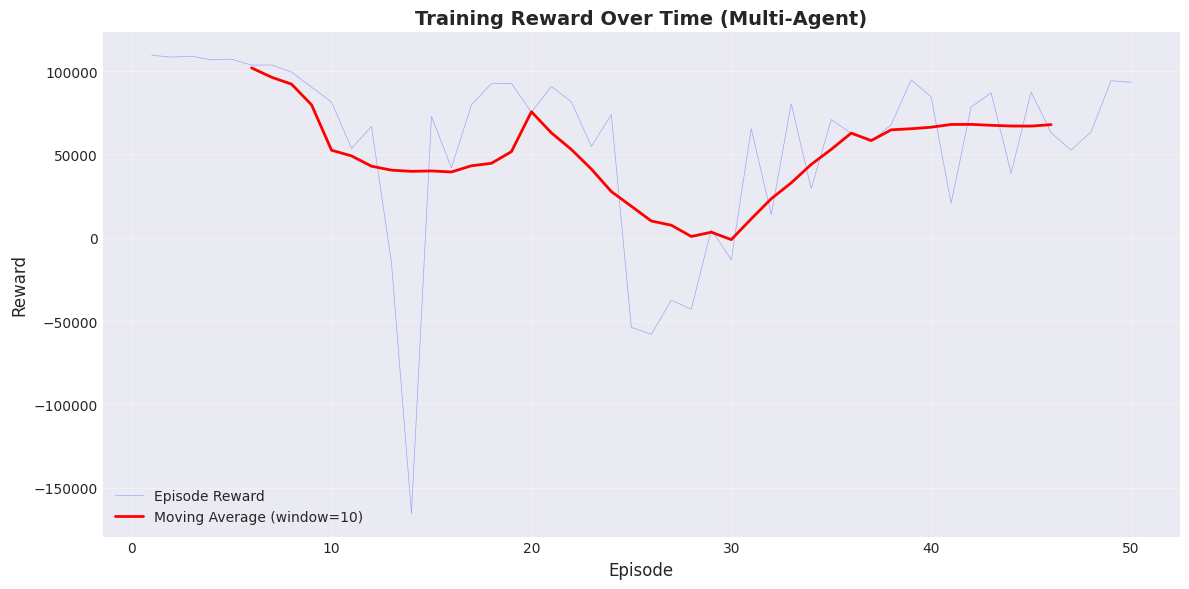

In [9]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    reward_col = 'reward' if 'reward' in df.columns else 'total_reward'
    title_suffix = ' (Multi-Agent)' if metrics.get('mode') == 'multi_agent_training' else ''
    
    ax.plot(df['episode'], df[reward_col], alpha=0.3, label='Episode Reward', color='blue', linewidth=0.5)
    if 'reward_ma' in df.columns:
        ax.plot(df['episode'], df['reward_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title(f'Training Reward Over Time{title_suffix}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Queue Length Over Time

Track how queue lengths change during training.


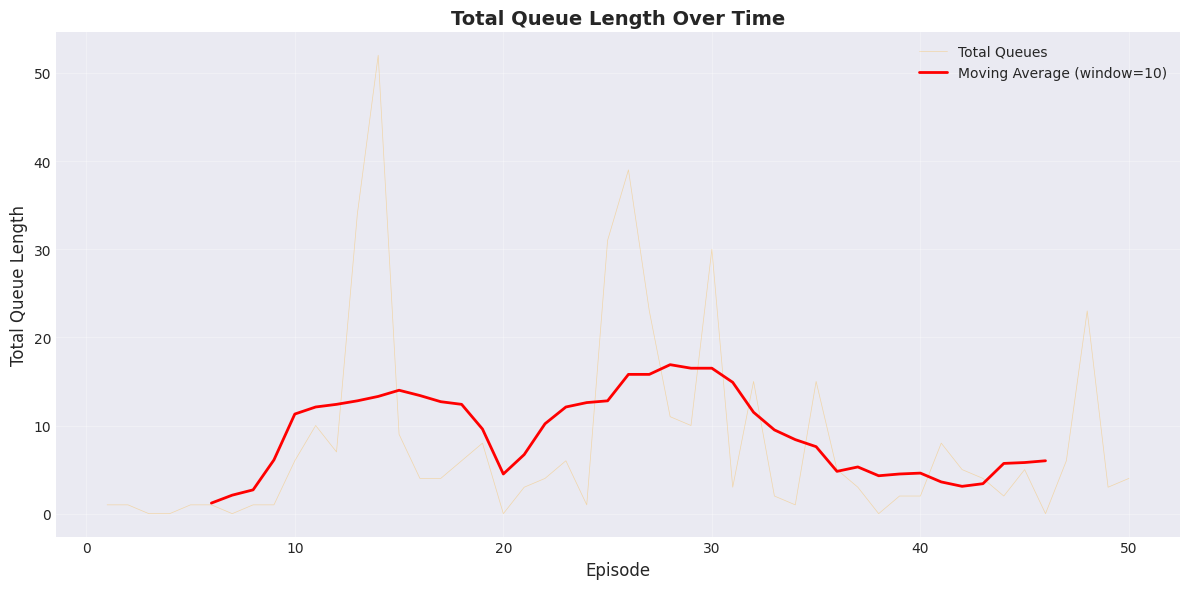

In [10]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['total_queues'], alpha=0.3, label='Total Queues', 
            color='orange', linewidth=0.5)
    if 'queues_ma' in df.columns:
        ax.plot(df['episode'], df['queues_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Queue Length', fontsize=12)
    ax.set_title('Total Queue Length Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Waiting Time Over Time

Monitor waiting times to assess traffic flow improvement.


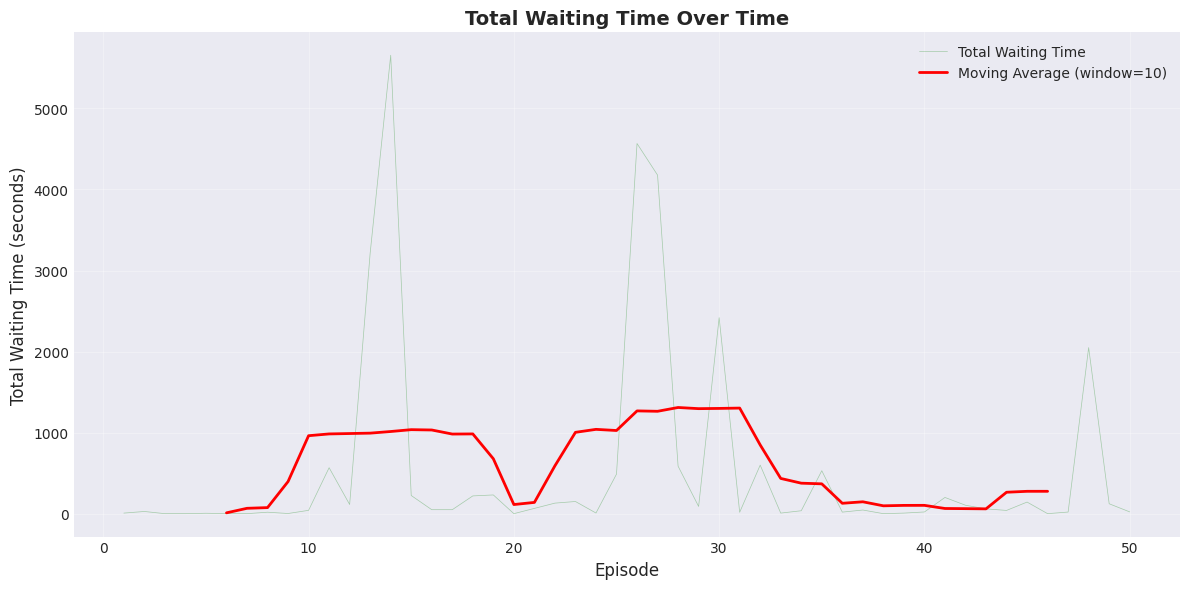

In [11]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['total_waiting_time'], alpha=0.3, label='Total Waiting Time', 
            color='green', linewidth=0.5)
    if 'waiting_ma' in df.columns:
        ax.plot(df['episode'], df['waiting_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Waiting Time (seconds)', fontsize=12)
    ax.set_title('Total Waiting Time Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Epsilon (Exploration Rate)

Track how exploration decreases over time as the agent becomes more confident.


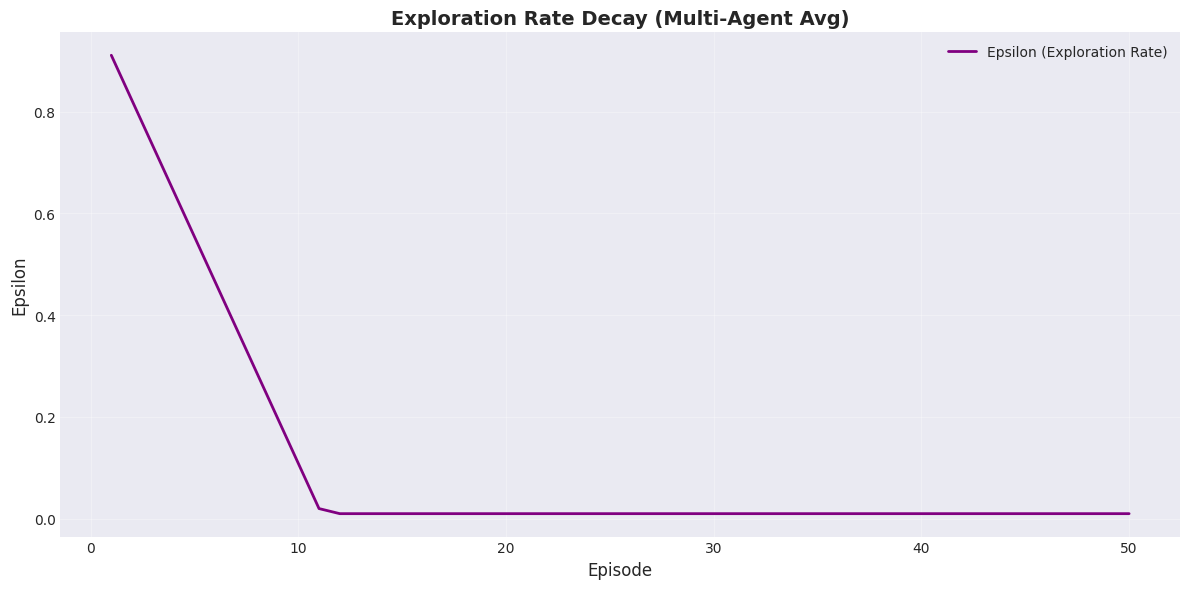

In [12]:
if df is not None:
    epsilon_col = 'epsilon' if 'epsilon' in df.columns else 'avg_epsilon'
    if epsilon_col in df.columns:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        title_suffix = ' (Multi-Agent Avg)' if metrics.get('mode') == 'multi_agent_training' else ''
        ax.plot(df['episode'], df[epsilon_col], label='Epsilon (Exploration Rate)', 
                color='purple', linewidth=2)
        
        ax.set_xlabel('Episode', fontsize=12)
        ax.set_ylabel('Epsilon', fontsize=12)
        ax.set_title(f'Exploration Rate Decay{title_suffix}', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Epsilon data not available in this run.")


## Visualization: Training Loss

If available, plot the training loss to monitor learning stability.


In [13]:
if df is not None and 'avg_loss' in df.columns and df['avg_loss'].notna().any():
    loss_data = df[df['avg_loss'].notna()]
    
    if len(loss_data) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(loss_data['episode'], loss_data['avg_loss'], alpha=0.3, 
                label='Episode Loss', color='darkred', linewidth=0.5)
        if 'loss_ma' in loss_data.columns:
            ax.plot(loss_data['episode'], loss_data['loss_ma'], 
                    label=f'Moving Average (window={window})', color='red', linewidth=2)
        
        ax.set_xlabel('Episode', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No loss data available.")
else:
    print("Loss tracking not available in this run.")


Loss tracking not available in this run.


## Visualization: Action Distribution

Analyze which actions the agent prefers over time.


In [14]:
if df is not None and 'action_distribution' in df.columns:
    # Extract action distributions
    action_data = []
    for idx, row in df.iterrows():
        dist = row['action_distribution']
        if dist:
            for action, count in dist.items():
                action_data.append({
                    'episode': row['episode'],
                    'action': int(action),
                    'count': count,
                    'percentage': count / sum(dist.values()) * 100
                })
    
    if action_data:
        action_df = pd.DataFrame(action_data)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: Action usage over time
        for action in sorted(action_df['action'].unique()):
            action_subset = action_df[action_df['action'] == action]
            axes[0].plot(action_subset['episode'], action_subset['percentage'], 
                        label=f'Action {action}', linewidth=2, alpha=0.7)
        
        axes[0].set_xlabel('Episode', fontsize=12)
        axes[0].set_ylabel('Action Usage (%)', fontsize=12)
        axes[0].set_title('Action Distribution Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Overall action distribution
        overall_dist = action_df.groupby('action')['count'].sum()
        axes[1].bar(overall_dist.index, overall_dist.values, alpha=0.7)
        axes[1].set_xlabel('Action', fontsize=12)
        axes[1].set_ylabel('Total Count', fontsize=12)
        axes[1].set_title('Overall Action Distribution', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No action distribution data available.")
else:
    print("Action distribution tracking not available in this run.")


Action distribution tracking not available in this run.


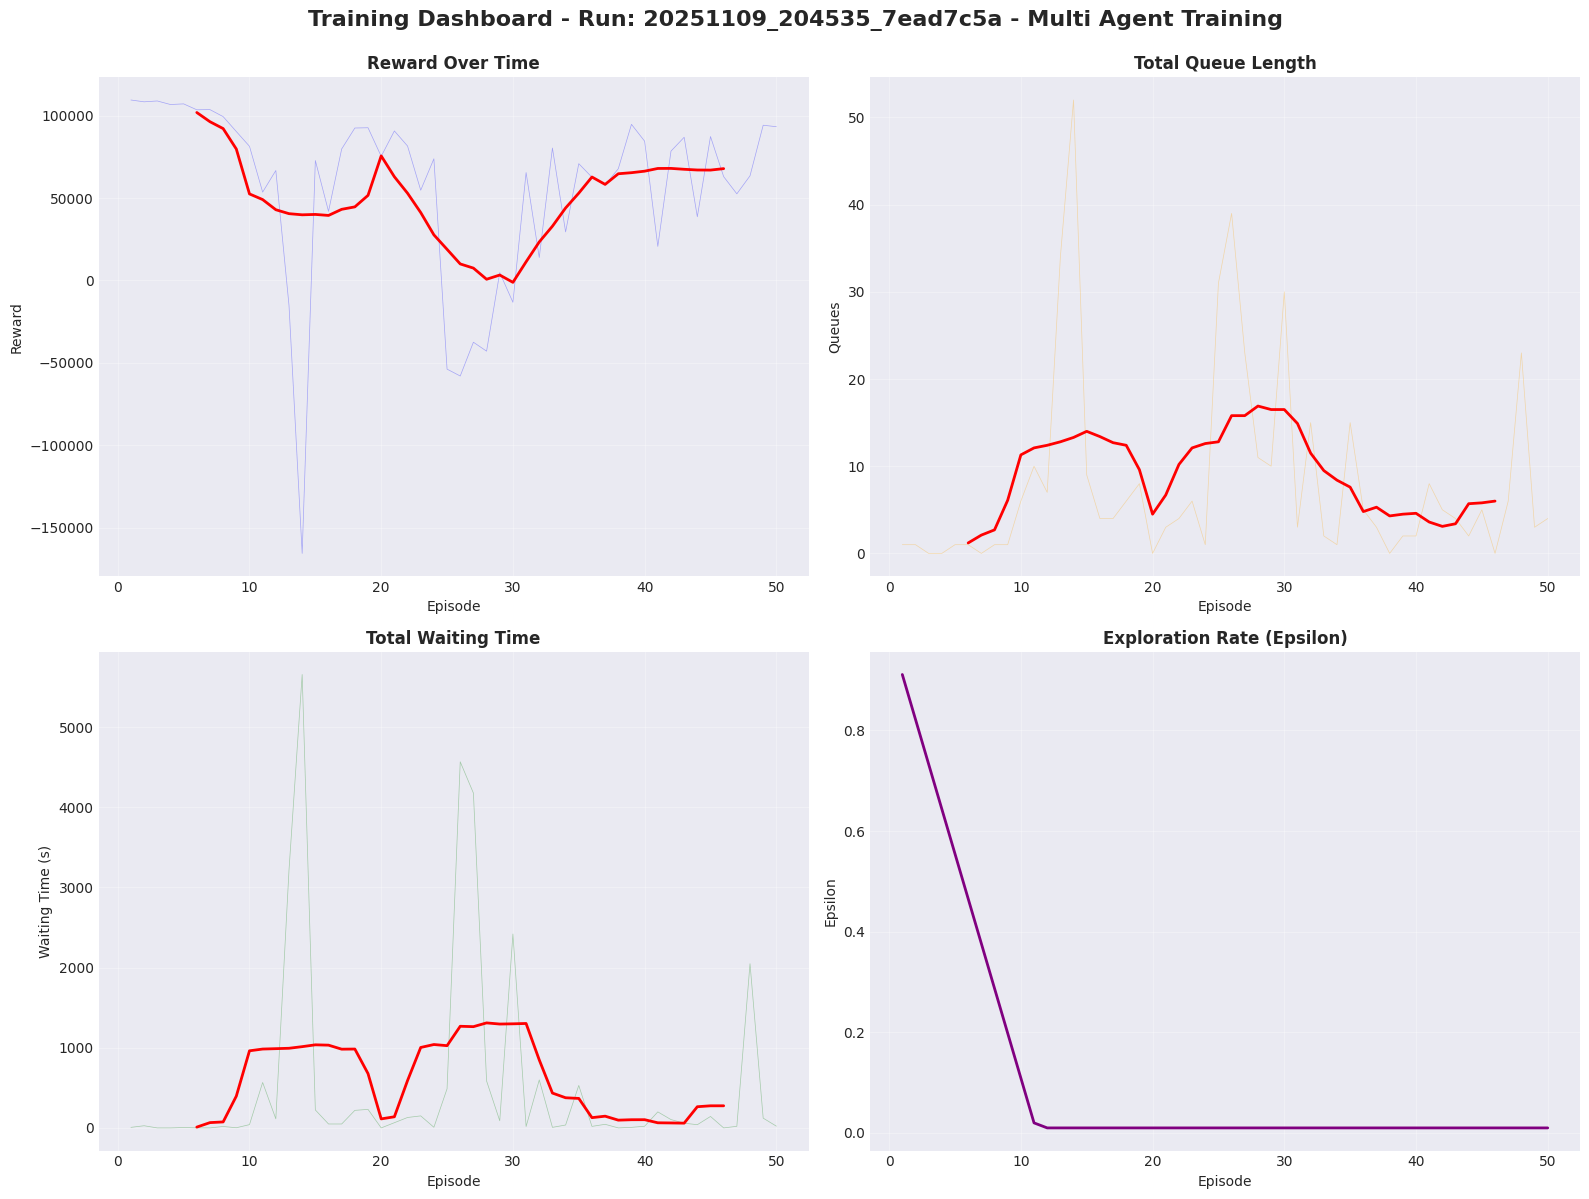

In [15]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    reward_col = 'reward' if 'reward' in df.columns else 'total_reward'
    epsilon_col = 'epsilon' if 'epsilon' in df.columns else 'avg_epsilon'
    
    # Reward
    axes[0, 0].plot(df['episode'], df[reward_col], alpha=0.3, color='blue', linewidth=0.5)
    if 'reward_ma' in df.columns:
        axes[0, 0].plot(df['episode'], df['reward_ma'], color='red', linewidth=2)
    axes[0, 0].set_title('Reward Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Queues
    if 'total_queues' in df.columns:
        axes[0, 1].plot(df['episode'], df['total_queues'], alpha=0.3, color='orange', linewidth=0.5)
        if 'queues_ma' in df.columns:
            axes[0, 1].plot(df['episode'], df['queues_ma'], color='red', linewidth=2)
        axes[0, 1].set_title('Total Queue Length', fontweight='bold')
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('Queues')
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No queue data', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Total Queue Length', fontweight='bold')
    
    # Waiting Time
    if 'total_waiting_time' in df.columns:
        axes[1, 0].plot(df['episode'], df['total_waiting_time'], alpha=0.3, color='green', linewidth=0.5)
        if 'waiting_ma' in df.columns:
            axes[1, 0].plot(df['episode'], df['waiting_ma'], color='red', linewidth=2)
        axes[1, 0].set_title('Total Waiting Time', fontweight='bold')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Waiting Time (s)')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No waiting time data', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Total Waiting Time', fontweight='bold')
    
    # Epsilon
    if epsilon_col in df.columns:
        axes[1, 1].plot(df['episode'], df[epsilon_col], color='purple', linewidth=2)
        axes[1, 1].set_title('Exploration Rate (Epsilon)', fontweight='bold')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Epsilon')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No epsilon data', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Exploration Rate (Epsilon)', fontweight='bold')
    
    mode_str = f" - {metrics.get('mode', 'unknown').replace('_', ' ').title()}"
    plt.suptitle(f'Training Dashboard - Run: {metrics.get("run_id", "unknown")}{mode_str}', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


## Per-Lane Analysis

Analyze performance for individual lanes.


In [16]:
if df is not None and 'queues' in df.columns:
    # Extract per-lane data
    num_lanes = len(df['queues'].iloc[0]) if len(df) > 0 and df['queues'].iloc[0] else 0
    
    if num_lanes > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Per-lane queues over time
        for lane_idx in range(num_lanes):
            lane_queues = df['queues'].apply(lambda x: x[lane_idx] if len(x) > lane_idx else 0)
            axes[0].plot(df['episode'], lane_queues, alpha=0.6, label=f'Lane {lane_idx}', linewidth=1.5)
        
        axes[0].set_xlabel('Episode', fontsize=12)
        axes[0].set_ylabel('Queue Length', fontsize=12)
        axes[0].set_title('Queue Length by Lane Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Per-lane waiting times over time
        for lane_idx in range(num_lanes):
            lane_waiting = df['waiting_times'].apply(lambda x: x[lane_idx] if len(x) > lane_idx else 0)
            axes[1].plot(df['episode'], lane_waiting, alpha=0.6, label=f'Lane {lane_idx}', linewidth=1.5)
        
        axes[1].set_xlabel('Episode', fontsize=12)
        axes[1].set_ylabel('Waiting Time (seconds)', fontsize=12)
        axes[1].set_title('Waiting Time by Lane Over Time', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No per-lane data available.")
else:
    print("Per-lane analysis not available.")


Per-lane analysis not available.


## Evaluation Metrics (if available)

If periodic evaluations were performed, analyze those results.


In [17]:
if 'evaluation_data' in metrics and metrics['evaluation_data']:
    eval_df = pd.DataFrame([
        {
            'episode': eval_data['episode'],
            'avg_reward': eval_data['metrics']['avg_reward'],
            'avg_queues': eval_data['metrics']['avg_total_queues'],
            'avg_waiting': eval_data['metrics']['avg_total_waiting_time']
        }
        for eval_data in metrics['evaluation_data']
    ])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(eval_df['episode'], eval_df['avg_reward'], marker='o', linewidth=2, markersize=8)
    axes[0].set_title('Evaluation Reward', fontweight='bold')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Average Reward')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(eval_df['episode'], eval_df['avg_queues'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].set_title('Evaluation Queues', fontweight='bold')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Queues')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(eval_df['episode'], eval_df['avg_waiting'], marker='o', linewidth=2, markersize=8, color='green')
    axes[2].set_title('Evaluation Waiting Time', fontweight='bold')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Average Waiting Time (s)')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Periodic Evaluation Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nEvaluation Summary:")
    print(eval_df.describe())
else:
    print("No evaluation data available (--eval-every was not used).")


No evaluation data available (--eval-every was not used).


## Configuration Summary

Display the training configuration used for this run.


In [18]:
print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

if config:
    for key, value in config.items():
        print(f"{key:25s}: {value}")
else:
    print("Configuration file not found.")

if 'config' in metrics:
    print("\nAdditional Metrics Config:")
    for key, value in metrics['config'].items():
        print(f"{key:25s}: {value}")


TRAINING CONFIGURATION
run_id                   : 20251109_204535_7ead7c5a
episodes                 : 50
max_steps                : 900
step_length              : 1.0
seed                     : None
learning_rate            : 0.001
batch_size               : 64
replay_size              : 50000
target_update            : 200
eval_every               : 0
eval_episodes            : 5
osm_file                 : maps/sanFrancisco.osm
flow_rate                : 1000
tls_id                   : None
device                   : cpu


## Compare Multiple Runs

Load and compare multiple training runs side by side.


## Multi-Agent Per-Agent Analysis

For multi-agent training, visualize individual agent performance.


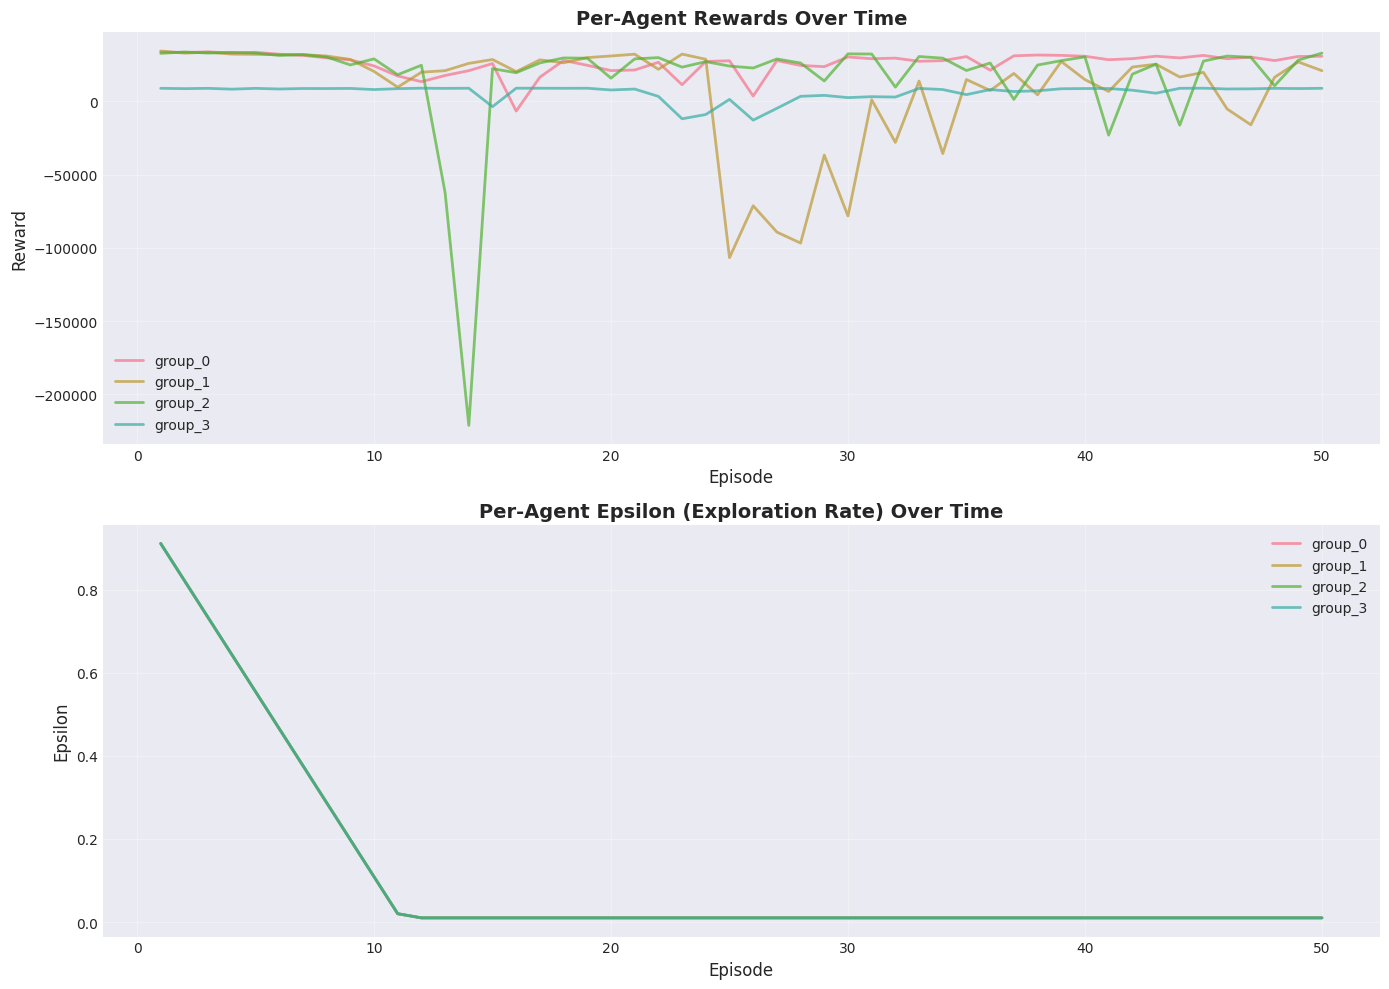


Per-Agent Final Statistics (last 10 episodes):

group_0:
  Final avg reward: 29716.42
  Best reward: 33690.70
  Worst reward: -6705.80

group_1:
  Final avg reward: 13428.04
  Best reward: 34262.20
  Worst reward: -106678.40

group_2:
  Final avg reward: 16416.05
  Best reward: 33630.70
  Worst reward: -221128.00

group_3:
  Final avg reward: 8270.96
  Best reward: 8923.60
  Worst reward: -12865.40


In [19]:
if df is not None and metrics.get('mode') == 'multi_agent_training' and 'agent_rewards' in df.columns:
    # Extract per-agent rewards
    agent_rewards_data = []
    for idx, row in df.iterrows():
        agent_rewards = row['agent_rewards']
        if isinstance(agent_rewards, dict):
            for agent_id, reward in agent_rewards.items():
                agent_rewards_data.append({
                    'episode': row['episode'],
                    'agent_id': agent_id,
                    'reward': reward
                })
    
    if agent_rewards_data:
        agent_rewards_df = pd.DataFrame(agent_rewards_data)
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Plot 1: Per-agent rewards over time
        for agent_id in sorted(agent_rewards_df['agent_id'].unique()):
            agent_data = agent_rewards_df[agent_rewards_df['agent_id'] == agent_id]
            axes[0].plot(agent_data['episode'], agent_data['reward'], 
                        label=f'{agent_id}', linewidth=2, alpha=0.7)
        
        axes[0].set_xlabel('Episode', fontsize=12)
        axes[0].set_ylabel('Reward', fontsize=12)
        axes[0].set_title('Per-Agent Rewards Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Per-agent epsilon over time
        if 'agent_epsilon' in df.columns:
            agent_epsilon_data = []
            for idx, row in df.iterrows():
                agent_epsilon = row['agent_epsilon']
                if isinstance(agent_epsilon, dict):
                    for agent_id, epsilon in agent_epsilon.items():
                        agent_epsilon_data.append({
                            'episode': row['episode'],
                            'agent_id': agent_id,
                            'epsilon': epsilon
                        })
            
            if agent_epsilon_data:
                agent_epsilon_df = pd.DataFrame(agent_epsilon_data)
                for agent_id in sorted(agent_epsilon_df['agent_id'].unique()):
                    agent_data = agent_epsilon_df[agent_epsilon_df['agent_id'] == agent_id]
                    axes[1].plot(agent_data['episode'], agent_data['epsilon'], 
                                label=f'{agent_id}', linewidth=2, alpha=0.7)
        
        axes[1].set_xlabel('Episode', fontsize=12)
        axes[1].set_ylabel('Epsilon', fontsize=12)
        axes[1].set_title('Per-Agent Epsilon (Exploration Rate) Over Time', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print per-agent statistics
        print("\nPer-Agent Final Statistics (last 10 episodes):")
        print("=" * 80)
        for agent_id in sorted(agent_rewards_df['agent_id'].unique()):
            agent_data = agent_rewards_df[agent_rewards_df['agent_id'] == agent_id]
            final_episodes = agent_data.nlargest(10, 'episode')
            print(f"\n{agent_id}:")
            print(f"  Final avg reward: {final_episodes['reward'].mean():.2f}")
            print(f"  Best reward: {agent_data['reward'].max():.2f}")
            print(f"  Worst reward: {agent_data['reward'].min():.2f}")
    else:
        print("No per-agent reward data available.")
elif df is not None and metrics.get('mode') != 'multi_agent_training':
    print("This is not a multi-agent training run. Per-agent analysis not applicable.")
else:
    print("No data available for per-agent analysis.")


In [20]:
def compare_runs(run_ids: List[str]) -> None:
    """Compare multiple training runs."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for run_id in run_ids:
        try:
            metrics, config, _ = load_metrics(run_id)
            if metrics.get('mode') == 'training' and 'episode_data' in metrics:
                df = pd.DataFrame(metrics['episode_data'])
                
                window = min(10, len(df) // 4)
                df['reward_ma'] = df['reward'].rolling(window=window, center=True).mean()
                df['queues_ma'] = df['total_queues'].rolling(window=window, center=True).mean()
                
                label = f"{run_id[:15]}..."
                
                axes[0, 0].plot(df['episode'], df['reward_ma'], label=label, linewidth=2)
                axes[0, 1].plot(df['episode'], df['queues_ma'], label=label, linewidth=2)
                axes[1, 0].plot(df['episode'], df['total_waiting_time'], label=label, linewidth=2, alpha=0.7)
                axes[1, 1].plot(df['episode'], df['epsilon'], label=label, linewidth=2)
        except Exception as e:
            print(f"Error loading run {run_id}: {e}")
    
    axes[0, 0].set_title('Reward Comparison', fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward (MA)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Queue Comparison', fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Queues (MA)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Waiting Time Comparison', fontweight='bold')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Waiting Time (s)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Epsilon Comparison', fontweight='bold')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Epsilon')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Uncomment and modify to compare specific runs:
# compare_runs(["run_id_1", "run_id_2", "run_id_3"])
